In [1]:
import numpy as np
import struct

def load_images(filepath, max_images=10000):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        num = min(num, max_images)
        images = np.frombuffer(f.read(num * rows * cols), dtype=np.uint8)
        images = images.reshape(num, rows * cols)
    return images

def load_labels(filepath, max_labels=10000):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        num = min(num, max_labels)
        labels = np.frombuffer(f.read(num), dtype=np.uint8)
    return labels

In [2]:
X_train = load_images(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\week4\train-images-idx3-ubyte")
y_train = load_labels(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\week4\train-labels-idx1-ubyte")
X_test = load_images(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\week4\t10k-images-idx3-ubyte")
y_test = load_labels(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\week4\t10k-labels-idx1-ubyte")

# Normalize pixel values from 0-255 to 0-1
X_train = (X_train / 255.0).astype(np.float32)
X_test = (X_test / 255.0).astype(np.float32)

# Use only 10,000 training samples instead of 60,000
X_train = X_train[:10000]
y_train = y_train[:10000]

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (10000, 784)
Training labels: (10000,)
Test images: (10000, 784)
Test labels: (10000,)


In [3]:
np.random.seed(42)

W1 = np.random.randn(784, 32) * 0.01
b1 = np.zeros((1, 32))
W2 = np.random.randn(32, 10) * 0.01
b2 = np.zeros((1, 10))

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (784, 32)
W2 shape: (32, 10)


In [4]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [5]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result

def backward(X, y, Z1, A1, A2, W2):
    m = X.shape[0]
    y_oh = one_hot(y)

    dZ2 = A2 - y_oh
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [6]:
learning_rate = 0.1
epochs = 20
batch_size = 64

for epoch in range(epochs):
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        Z1, A1, Z2, A2 = forward(X_batch, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(X_batch, y_batch, Z1, A1, A2, W2)

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    _, _, _, A2_train = forward(X_train, W1, b1, W2, b2)
    train_acc = np.mean(np.argmax(A2_train, axis=1) == y_train)
    print(f"Epoch {epoch+1}/{epochs} - Train Accuracy: {train_acc*100:.2f}%")

Epoch 1/20 - Train Accuracy: 80.15%
Epoch 2/20 - Train Accuracy: 88.02%
Epoch 3/20 - Train Accuracy: 89.82%
Epoch 4/20 - Train Accuracy: 89.63%
Epoch 5/20 - Train Accuracy: 92.31%
Epoch 6/20 - Train Accuracy: 92.67%
Epoch 7/20 - Train Accuracy: 92.19%
Epoch 8/20 - Train Accuracy: 93.40%
Epoch 9/20 - Train Accuracy: 94.06%
Epoch 10/20 - Train Accuracy: 94.19%
Epoch 11/20 - Train Accuracy: 94.07%
Epoch 12/20 - Train Accuracy: 93.05%
Epoch 13/20 - Train Accuracy: 95.12%
Epoch 14/20 - Train Accuracy: 95.68%
Epoch 15/20 - Train Accuracy: 94.91%
Epoch 16/20 - Train Accuracy: 96.03%
Epoch 17/20 - Train Accuracy: 95.76%
Epoch 18/20 - Train Accuracy: 96.08%
Epoch 19/20 - Train Accuracy: 96.24%
Epoch 20/20 - Train Accuracy: 95.95%


In [7]:
_, _, _, A2_test = forward(X_test, W1, b1, W2, b2)
test_acc = np.mean(np.argmax(A2_test, axis=1) == y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 92.31%


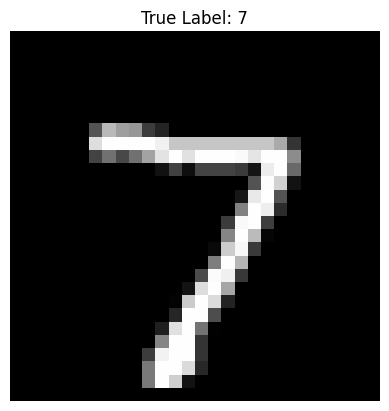

Predicted: 7


In [8]:
import matplotlib.pyplot as plt

index = 0
image = X_test[index].reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.title(f"True Label: {y_test[index]}")
plt.axis('off')
plt.show()

_, _, _, pred = forward(X_test[index:index+1], W1, b1, W2, b2)
print(f"Predicted: {np.argmax(pred)}")